# 03 — Spatial Structure Within Imaging Sites

## Student Notebook

This notebook focuses on the spatial coordinates in the dataset.

The key question is simple: **where are cells located within a field of view, and how do signaling and morphology vary across space?**

We will look at:

- what the X/Y columns mean,
- how cells are distributed in one representative image,
- whether ERK, FoxO, or nuclear size appear spatially patterned,
- how local cell density can be summarized from positions.

The purpose is exploratory. We are not yet proving a spatial mechanism. We are learning how to read spatial structure from coordinates.

In [5]:
from pathlib import Path
import os
import tempfile

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'mpl-config'))

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 50)

ROOT = Path.cwd()
if not (ROOT / 'single-cell-tracks_exp1-6_noErbB2.csv.gz').exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH = ROOT / '01-readme-experiment-description_2022-04-05.csv'

meta = pd.read_csv(META_PATH, encoding='utf-8-sig').rename(columns={'Site': 'Image_Metadata_Site'})
meta['Image_Metadata_Site'] = meta['Image_Metadata_Site'].astype(int)
site_to_mutation = meta.set_index('Image_Metadata_Site')['Mutation'].to_dict()

print('Ready to explore spatial coordinates from:', DATA_PATH)

Ready to explore spatial coordinates from: /Users/krzysiek/PROJECTS-MIMUW/UW-SysBiol-Project2/single-cell-tracks_exp1-6_noErbB2.csv.gz


## How Should We Interpret X and Y?

The columns `objNuclei_Location_Center_X` and `objNuclei_Location_Center_Y` give the position of each segmented nucleus inside an image.

That means:

- they are spatial coordinates within one microscopy field of view,
- they are not global coordinates across the whole experiment,
- they become meaningful when we compare cells **within the same site and time point**.

So in this notebook we mostly inspect one representative snapshot at a time.
That keeps the biological interpretation clean: cells in the same image can plausibly interact or share local context.

In [6]:
space_cols = [
    'Exp_ID', 'Image_Metadata_Site', 'Image_Metadata_T',
    'ERKKTR_ratio', 'FoxO3A_ratio', 'Nuclear_size',
    'objNuclei_Location_Center_X', 'objNuclei_Location_Center_Y'
]

sample = pd.read_csv(DATA_PATH, usecols=space_cols, nrows=500_000)
sample['Mutation'] = sample['Image_Metadata_Site'].map(site_to_mutation)

site_time_counts = (
    sample
    .groupby(['Exp_ID', 'Image_Metadata_Site', 'Image_Metadata_T', 'Mutation'])
    .size()
    .reset_index(name='n_cells')
    .sort_values('n_cells', ascending=False)
)

chosen = site_time_counts.iloc[0]
exp_id = int(chosen['Exp_ID'])
site_id = int(chosen['Image_Metadata_Site'])
time_idx = int(chosen['Image_Metadata_T'])
mutation = chosen['Mutation']

snapshot = (
    sample[
        (sample['Exp_ID'] == exp_id)
        & (sample['Image_Metadata_Site'] == site_id)
        & (sample['Image_Metadata_T'] == time_idx)
    ]
    .copy()
    .reset_index(drop=True)
)

print(f'Representative snapshot: Exp_ID={exp_id}, Site={site_id}, Mutation={mutation}, T={time_idx}')
print('Cells in snapshot:', len(snapshot))
display(snapshot.head())

Representative snapshot: Exp_ID=1, Site=1, Mutation=WT, T=6
Cells in snapshot: 1412


,Exp_ID,Image_Metadata_Site,Image_Metadata_T,Nuclear_size,ERKKTR_ratio,FoxO3A_ratio,objNuclei_Location_Center_X,objNuclei_Location_Center_Y,Mutation
0,1,1,6,327.000,1.165190,1.39633,931.080,872.2600,WT
1,1,1,6,266.000,1.226480,1.22075,159.921,365.1690,WT
2,1,1,6,367.000,0.749038,1.30630,650.027,847.1470,WT
3,1,1,6,356.001,0.770714,1.33927,642.697,829.8150,WT
4,1,1,6,312.000,1.229490,1.53940,988.644,59.6314,WT


## Visualizing a Spatial Snapshot

The next plot shows the same cells in the same image, but colors them by different variables.

This is an important exploratory technique: keep the geometry fixed, and change only the coloring variable.
That helps us ask whether a quantity appears spatially structured.

For example:

- do high-ERK cells cluster in one region?
- does FoxO look smooth or patchy in space?
- is nuclear size larger in specific areas of the field?

A pattern in a single image is not proof, but it is often the first clue that a spatial question is worth pursuing.

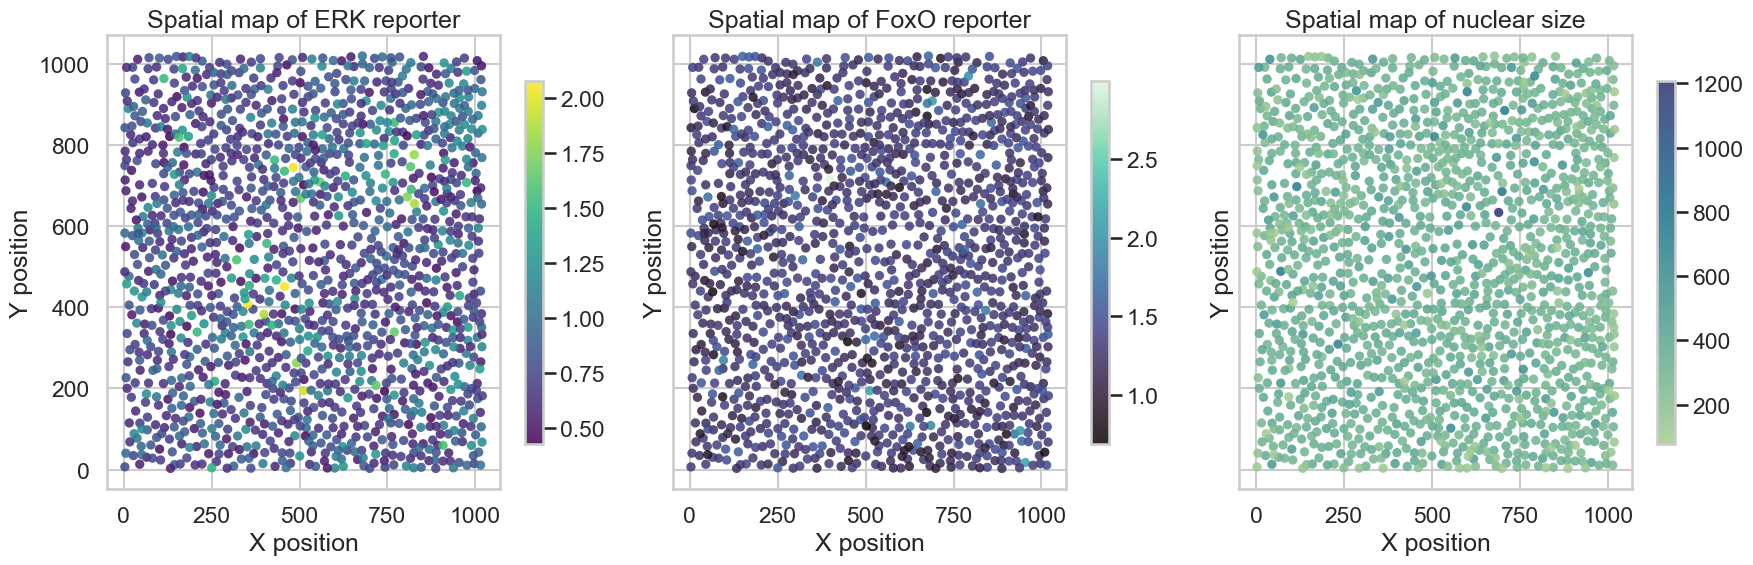

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

for ax, value_col, title, cmap in [
    (axes[0], 'ERKKTR_ratio', 'Spatial map of ERK reporter', 'viridis'),
    (axes[1], 'FoxO3A_ratio', 'Spatial map of FoxO reporter', 'mako'),
    (axes[2], 'Nuclear_size', 'Spatial map of nuclear size', 'crest'),
]:
    sc = ax.scatter(
        snapshot['objNuclei_Location_Center_X'],
        snapshot['objNuclei_Location_Center_Y'],
        c=snapshot[value_col],
        cmap=cmap,
        s=45,
        alpha=0.85,
        edgecolor='none'
    )
    ax.set_title(title)
    ax.set_xlabel('X position')
    ax.set_ylabel('Y position')
    plt.colorbar(sc, ax=ax, shrink=0.8)

plt.tight_layout()

## Local Density and Neighborhood Context

Spatial data are not only about positions; they are also about **local context**.

A simple first summary is to ask:

- how close is each cell to its nearest neighbor?
- how many nearby cells does each cell have?

These are not yet full models of cell-cell interaction, but they are useful exploratory variables.
They help us think about whether crowding, neighborhoods, or local organization could matter for signaling.

,count,mean,std,min,25%,50%,75%,max
ERKKTR_ratio,1412.0,0.828242,0.247966,0.429638,0.641517,0.769731,0.963110,2.077730
FoxO3A_ratio,1412.0,1.295555,0.172395,0.689828,1.200133,1.297420,1.385433,2.998910
Nuclear_size,1412.0,322.421369,88.726939,78.000300,278.000000,319.999000,361.999250,1208.000000
nearest_neighbor_dist,1412.0,20.877486,3.929798,10.422859,18.209245,20.542953,23.261554,37.869604
local_neighbors,1412.0,14.494334,3.131758,4.000000,13.000000,15.000000,16.000000,25.000000


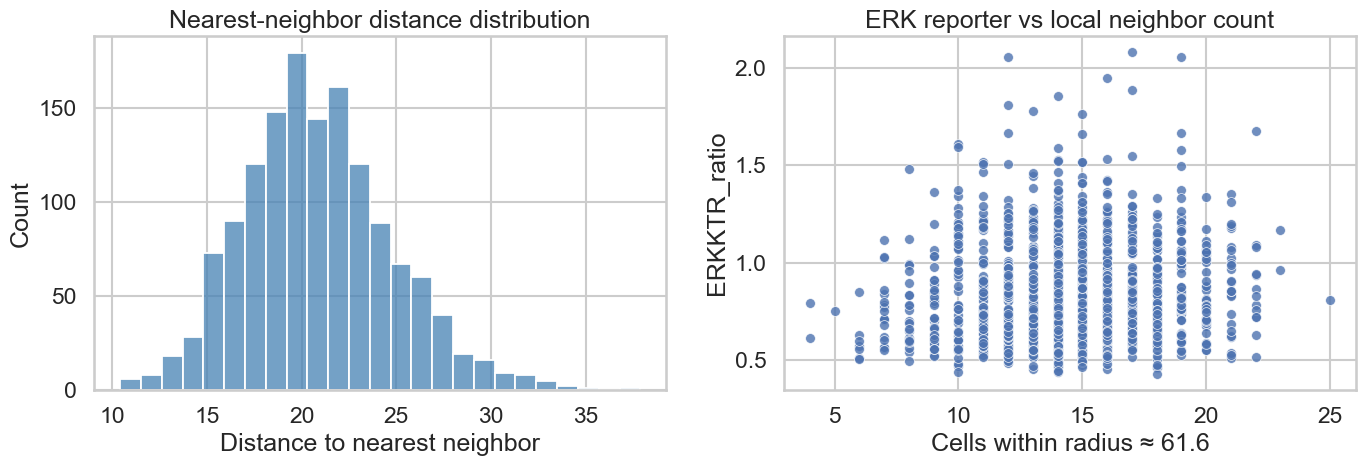

In [9]:
coords = snapshot[['objNuclei_Location_Center_X', 'objNuclei_Location_Center_Y']].to_numpy()
tree = cKDTree(coords)

dists, _ = tree.query(coords, k=2)
snapshot['nearest_neighbor_dist'] = dists[:, 1]
radius = float(np.median(snapshot['nearest_neighbor_dist']) * 3)
snapshot['local_neighbors'] = [len(idx) - 1 for idx in tree.query_ball_point(coords, r=radius)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(snapshot['nearest_neighbor_dist'], bins=25, ax=axes[0], color='steelblue')
axes[0].set_title('Nearest-neighbor distance distribution')
axes[0].set_xlabel('Distance to nearest neighbor')

sns.scatterplot(data=snapshot, x='local_neighbors', y='ERKKTR_ratio', ax=axes[1], alpha=0.8, s=50)
axes[1].set_title('ERK reporter vs local neighbor count')
axes[1].set_xlabel(f'Cells within radius ≈ {radius:.1f}')
axes[1].set_ylabel('ERKKTR_ratio')

plt.tight_layout()

display(snapshot[['ERKKTR_ratio', 'FoxO3A_ratio', 'Nuclear_size', 'nearest_neighbor_dist', 'local_neighbors']].describe().T)

## Nearest-Neighbor Distance Across Conditions

So far we looked at one representative snapshot. A natural next question is whether spacing between cells differs more broadly across the conditions represented in the dataset.

In this dataset, the column `Conditions` is effectively constant, so the meaningful condition-like grouping is **mutation**. The code below therefore compares nearest-neighbor distances across mutations.

This is still exploratory. If one mutation shows systematically shorter nearest-neighbor distances, that suggests a difference in local packing or spatial organization. It does **not** yet tell us why that difference exists.

,n_cells,mean_nearest_neighbor_dist,median_nearest_neighbor_dist,std_nearest_neighbor_dist
Mutation,,,,
WT,500000,22.863051,21.800674,5.990078


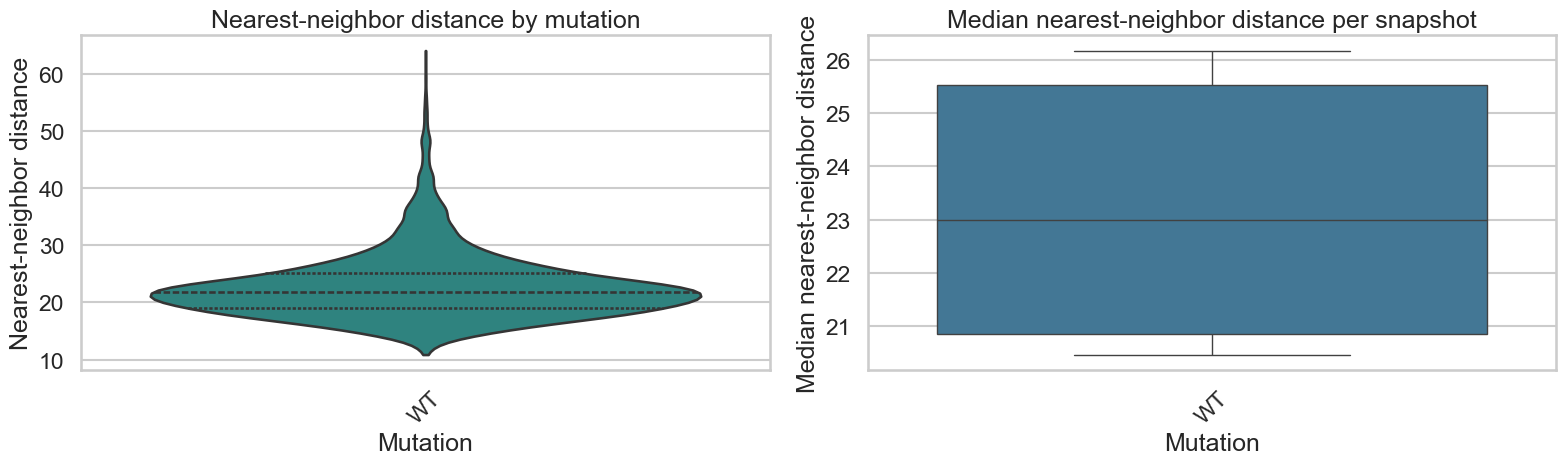

In [10]:
nn_rows = []
for (exp_id_all, site_id_all, time_idx_all, mutation_all), grp in sample.groupby(
    ['Exp_ID', 'Image_Metadata_Site', 'Image_Metadata_T', 'Mutation'],
    sort=False,
):
    if len(grp) < 2:
        continue

    coords_all = grp[['objNuclei_Location_Center_X', 'objNuclei_Location_Center_Y']].to_numpy()
    tree_all = cKDTree(coords_all)
    dists_all, _ = tree_all.query(coords_all, k=2)

    nn_rows.append(
        pd.DataFrame(
            {
                'Exp_ID': exp_id_all,
                'Image_Metadata_Site': site_id_all,
                'Image_Metadata_T': time_idx_all,
                'Mutation': mutation_all,
                'nearest_neighbor_dist': dists_all[:, 1],
            }
        )
    )

nn_by_condition = pd.concat(nn_rows, ignore_index=True)
condition_summary = (
    nn_by_condition
    .groupby('Mutation')
    .agg(
        n_cells=('nearest_neighbor_dist', 'size'),
        mean_nearest_neighbor_dist=('nearest_neighbor_dist', 'mean'),
        median_nearest_neighbor_dist=('nearest_neighbor_dist', 'median'),
        std_nearest_neighbor_dist=('nearest_neighbor_dist', 'std'),
    )
    .sort_values('median_nearest_neighbor_dist')
)

display(condition_summary)

plot_nn = pd.concat(
    [
        grp.sample(min(len(grp), 5000), random_state=0)
        for _, grp in nn_by_condition.groupby('Mutation', sort=False)
    ],
    ignore_index=True,
)

snapshot_nn = (
    nn_by_condition
    .groupby(['Mutation', 'Exp_ID', 'Image_Metadata_Site', 'Image_Metadata_T'], as_index=False)
    .agg(nearest_neighbor_dist=('nearest_neighbor_dist', 'median'))
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.violinplot(data=plot_nn, x='Mutation', y='nearest_neighbor_dist', hue='Mutation', legend=False, inner='quartile', cut=0, ax=axes[0], palette='viridis')
axes[0].set_title('Nearest-neighbor distance by mutation')
axes[0].set_xlabel('Mutation')
axes[0].set_ylabel('Nearest-neighbor distance')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=snapshot_nn, x='Mutation', y='nearest_neighbor_dist', hue='Mutation', legend=False, ax=axes[1], palette='mako')
axes[1].set_title('Median nearest-neighbor distance per snapshot')
axes[1].set_xlabel('Mutation')
axes[1].set_ylabel('Median nearest-neighbor distance')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

## What to Take Away

Spatial exploration begins by treating coordinates as biological information rather than as extra bookkeeping columns.

From this notebook, the important habits are:

- compare cells within the same site and time point,
- keep the geometry fixed while changing what is colored or summarized,
- use local neighborhood summaries as exploratory variables,
- stay cautious: spatial pattern in one snapshot is a clue, not a conclusion.

These ideas set up the next step: asking whether nearby cells behave in coordinated ways, which is a question about collective behavior rather than only spatial arrangement.